In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
mnist_train = pd.read_csv("/content/drive/MyDrive/mnist_train.csv")
mnist_test = pd.read_csv("/content/drive/MyDrive/mnist_test.csv")

In [18]:
mnist_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
y_train = mnist_train['label'].copy().to_numpy()
x_train = mnist_train.drop('label', axis=1).copy().to_numpy()

In [20]:
print('The training digits data:', x_train)
print('Digits labels:' , y_train)

The training digits data: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Digits labels: [5 0 4 ... 5 6 8]


In [21]:
y_test = mnist_test['label'].copy().to_numpy()
x_test = mnist_test.drop('label', axis=1).copy().to_numpy()

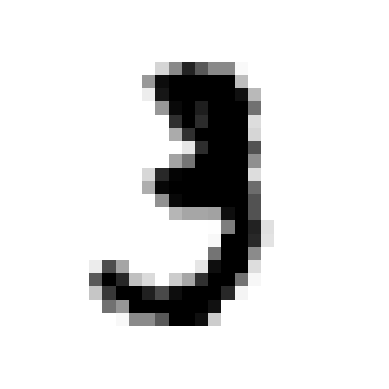

In [23]:
any_digit = x_train[10]
any_digit_image = any_digit.reshape(28, 28)
plt.imshow(any_digit_image, cmap='binary')
plt.axis('off')
plt.show()

In [24]:
print(y_train[10])

3


In [25]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [26]:
knn.predict([any_digit])

array([3])

In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
knn_pred = cross_val_predict(knn, x_train, y_train, cv = 3)

In [29]:
knn_pred

array([5, 0, 4, ..., 5, 6, 8])

In [30]:
cf_mat = confusion_matrix(y_train, knn_pred)

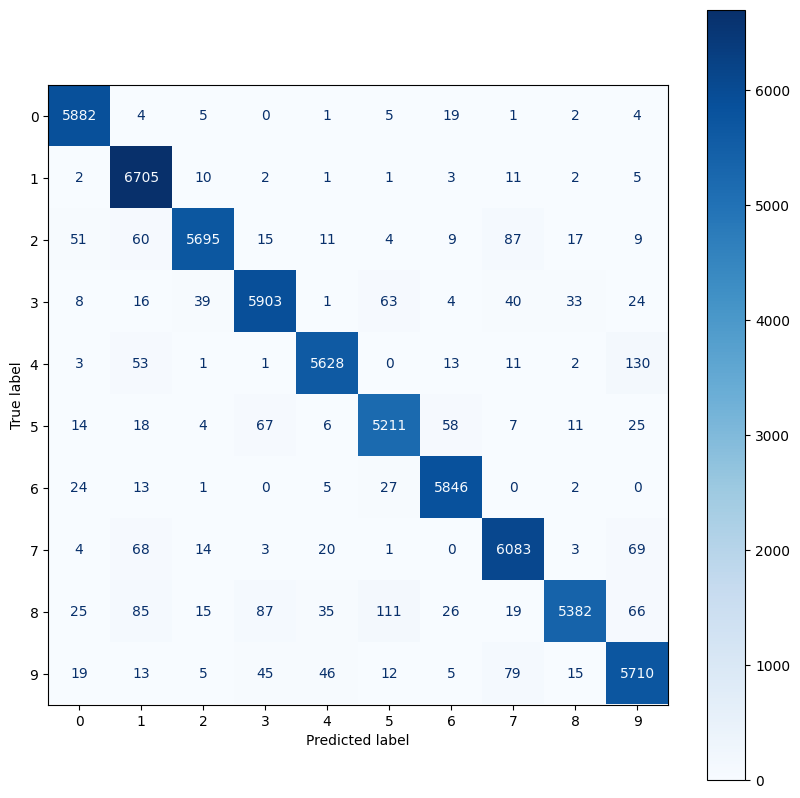

In [33]:
cm_fig, cm_ax = plt.subplots(figsize=(10,10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat)
cf_mat_disp.plot(ax= cm_ax, cmap= plt.cm.Blues)
plt.show()

In [36]:
from sklearn.metrics import classification_report

def class_report(y, y_pred):
  print('classification report:', classification_report(y, y_pred, digits= 5))

In [37]:
class_report(y_train, knn_pred)

classification report:               precision    recall  f1-score   support

           0    0.97513   0.99308   0.98402      5923
           1    0.95309   0.99451   0.97336      6742
           2    0.98376   0.95586   0.96961      5958
           3    0.96407   0.96281   0.96344      6131
           4    0.97810   0.96337   0.97068      5842
           5    0.95879   0.96126   0.96002      5421
           6    0.97710   0.98783   0.98244      5918
           7    0.95977   0.97095   0.96533      6265
           8    0.98409   0.91984   0.95088      5851
           9    0.94505   0.95983   0.95238      5949

    accuracy                        0.96742     60000
   macro avg    0.96790   0.96693   0.96722     60000
weighted avg    0.96768   0.96742   0.96735     60000



In [41]:
knn_tuned = KNeighborsClassifier(n_neighbors=3, weights='distance')

knn_tuned.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [42]:
y_test_preds = knn_tuned.predict(x_test)

In [43]:
class_report(y_test, y_test_preds)

classification report:               precision    recall  f1-score   support

           0    0.97303   0.99388   0.98334       980
           1    0.96590   0.99824   0.98180      1135
           2    0.98421   0.96609   0.97506      1032
           3    0.96630   0.96535   0.96582      1010
           4    0.97631   0.96538   0.97081       982
           5    0.96413   0.96413   0.96413       892
           6    0.98129   0.98539   0.98333       958
           7    0.96225   0.96693   0.96458      1028
           8    0.98717   0.94764   0.96700       974
           9    0.95846   0.96036   0.95941      1009

    accuracy                        0.97170     10000
   macro avg    0.97190   0.97134   0.97153     10000
weighted avg    0.97181   0.97170   0.97166     10000

